In [7]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
pwd = os.getcwd()
filepath = os.path.join(pwd, "housing.csv")
filepath

'/content/housing.csv'

In [9]:
housing_data = pd.read_csv(filepath)
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


<Axes: xlabel='ocean_proximity'>

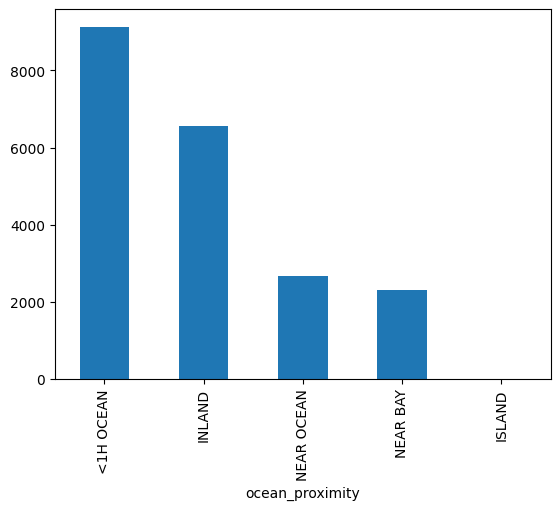

In [11]:
housing_data["ocean_proximity"].value_counts().plot(kind="bar")

In [12]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<Axes: >

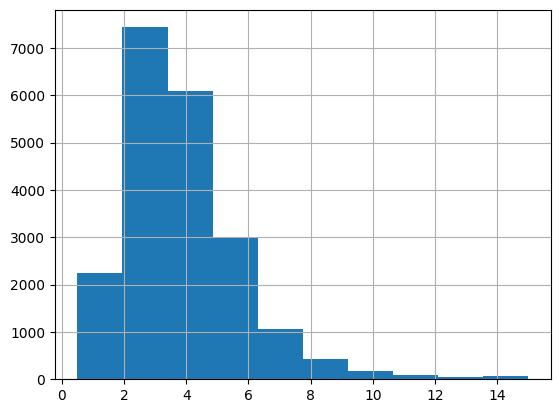

In [13]:
housing_data["median_income"].hist()

In [14]:
housing_data["income_cat"] = pd.cut(housing_data["median_income"],
                                    bins = [0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels= [1 , 2 , 3 , 4 , 5])
housing_data["income_cat"].value_counts()

,count
income_cat,
3,7236
2,6581
4,3639
5,2362
1,822


<Axes: >

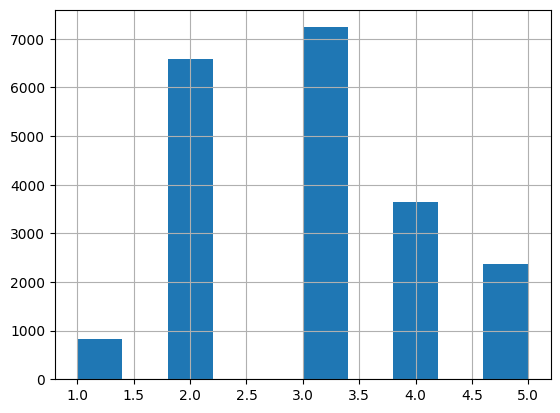

In [15]:
housing_data["income_cat"].hist()

In [16]:
y = housing_data["median_house_value"]
X = housing_data.drop("median_house_value", axis=1)
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,2


Split Datasets
------------------------------------


In [17]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y ,  test_size=0.33)
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
3492,-118.48,34.28,35.0,2132.0,368.0,1128.0,341.0,5.3107,<1H OCEAN,4
15992,-122.47,37.75,49.0,2747.0,472.0,1281.0,448.0,5.4820,NEAR BAY,4
12601,-121.48,38.53,37.0,1704.0,361.0,902.0,356.0,1.9837,INLAND,2
13909,-116.40,34.12,16.0,5648.0,1089.0,2524.0,1008.0,2.6739,INLAND,2
10738,-117.91,33.60,37.0,2088.0,510.0,673.0,390.0,5.1048,<1H OCEAN,4
...,...,...,...,...,...,...,...,...,...,...
19123,-122.65,38.24,24.0,1948.0,310.0,922.0,313.0,4.9500,<1H OCEAN,4
15100,-116.95,32.82,18.0,3038.0,592.0,1904.0,595.0,3.8024,<1H OCEAN,3
4953,-118.31,34.01,39.0,2073.0,566.0,1246.0,547.0,2.0417,<1H OCEAN,2
16229,-121.33,37.97,43.0,1511.0,292.0,721.0,320.0,3.5703,INLAND,3


<Axes: >

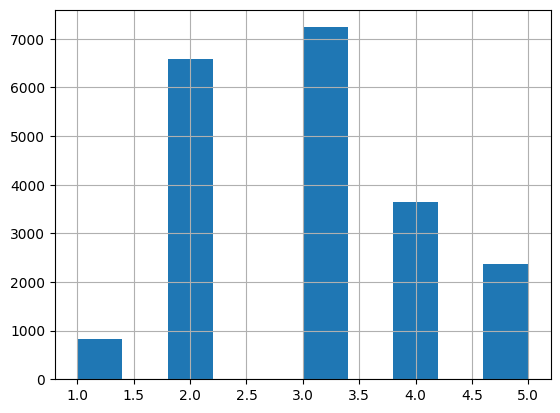

In [18]:
housing_data["income_cat"].hist()

<Axes: >

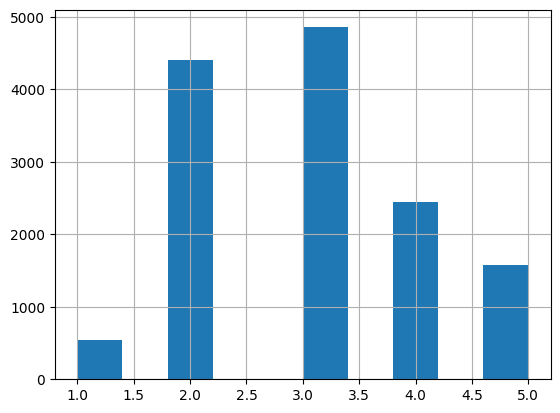

In [19]:
X_train["income_cat"].hist()

Stratified Split

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index , test_index in split.split(housing_data, housing_data["income_cat"]):
  strat_train_set = housing_data.loc[train_index]
  strat_test_set = housing_data.loc[test_index]

In [21]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [22]:
housing_data["income_cat"].value_counts() / len(housing_data)

,count
income_cat,
3,0.350581
2,0.318847
4,0.176308
5,0.114438
1,0.039826


In [23]:
def income_cat_proportions(data):
  return data["income_cat"].value_counts() / len(data)

train_set , test_set = train_test_split(housing_data, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing_data),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [24]:
strat_train_set.drop("income_cat", axis=1, inplace=True)
strat_test_set.drop("income_cat", axis=1, inplace=True)

**Visualization the data**

In [25]:
housing = strat_train_set.copy()

**Histograms**

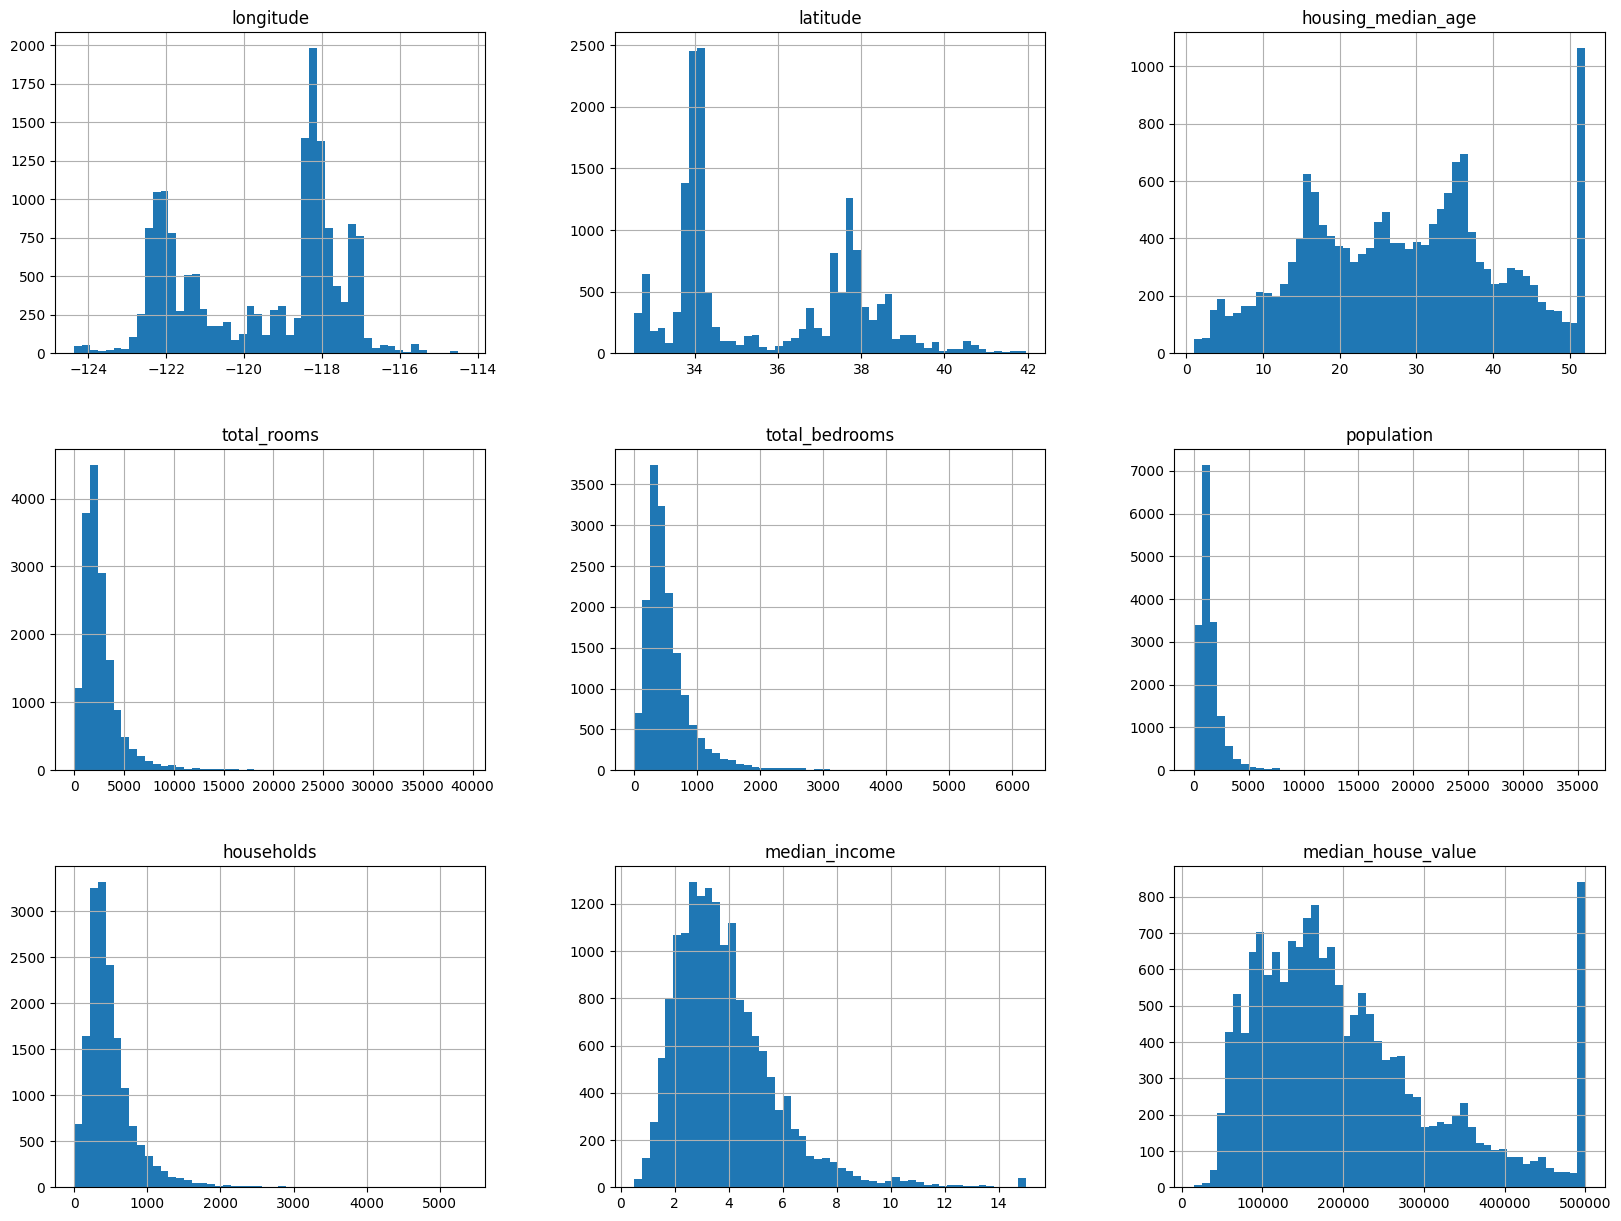

In [27]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

<Axes: >

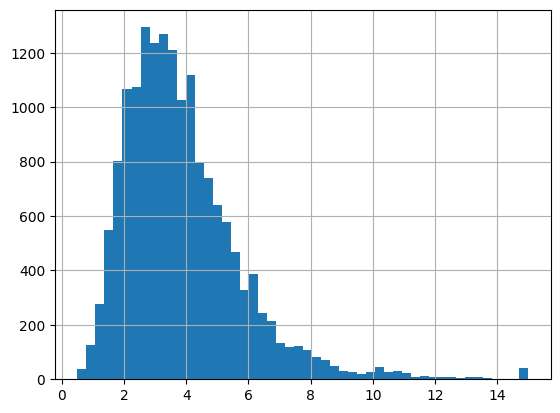

In [28]:
housing['median_income'].hist(bins=50)

Geographic Data

<Axes: xlabel='longitude', ylabel='latitude'>

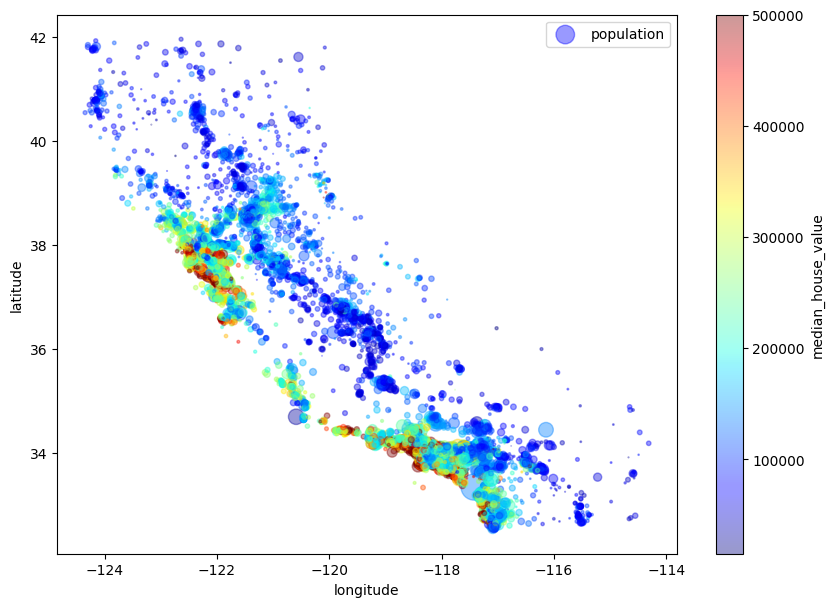

In [29]:
housing.plot(kind="scatter", x="longitude", y="latitude" , alpha = 0.4 ,
             s= housing["population"]/100 , label = "population" , figsize= (10,7) ,
             c = "median_house_value" , cmap = plt.get_cmap("jet") , colorbar = True , sharex=False)

**Correlation Matrecis**

In [30]:
housing.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


<Axes: >

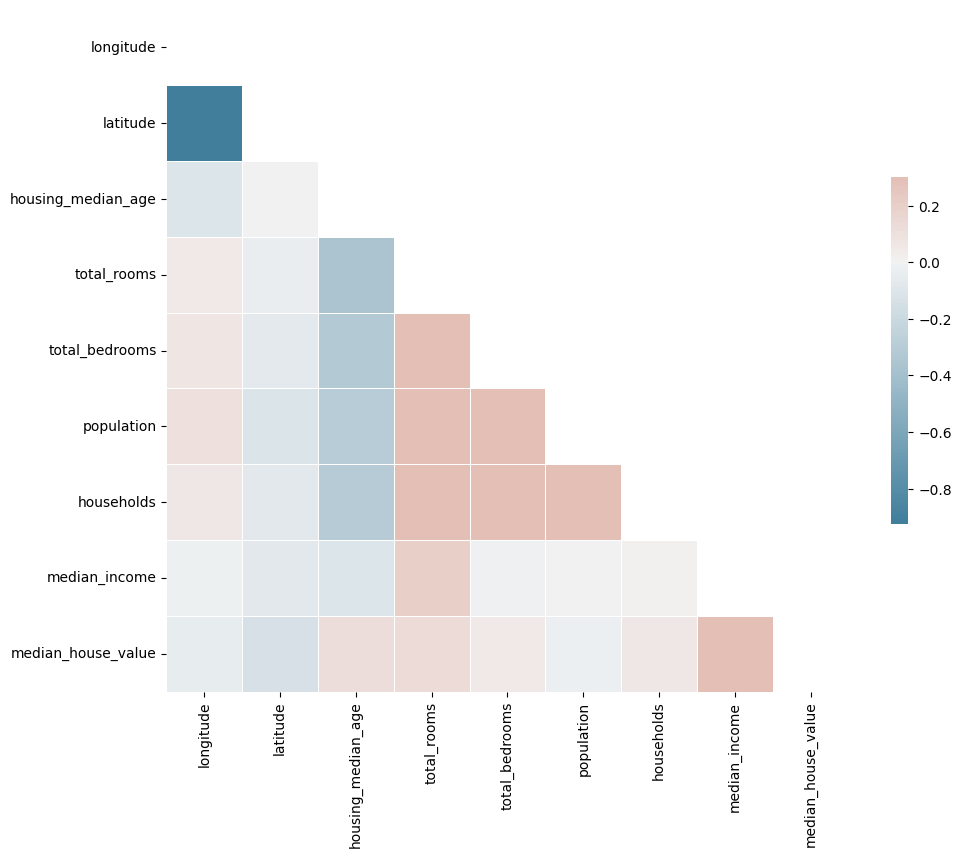

In [31]:
corr = housing.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
f , ax = plt.subplots(figsize=(11,9))
cmap = sns.diverging_palette(230 , 20 , as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap , vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

**Preparing Data for Machine Learning**

In [32]:
housing= strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

**Dealing with Missing Values**

In [33]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN


In [34]:
sample_incomplete_rows.drop("total_bedrooms" , axis =1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,1145.0,480.0,6.3580,NEAR OCEAN


In [35]:
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True)
sample_incomplete_rows

/tmp/ipykernel_356/823266087.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580,NEAR OCEAN


In [36]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [37]:
housing_num = housing.select_dtypes(include=[np.number])
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


In [38]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [39]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,2


In [40]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns , index=housing_num.index)
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


In [41]:
imputer.strategy

'median'

**Encode Categorical Variable**

In [44]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat = housing[['ocean_proximity']]
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [45]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

**Feature Engineering**

In [46]:
def feature_engineering(data):
  data["rooms_per_household"] = data["total_rooms"] / data["households"]
  data["population_per_household"] = data["population"] / data["households"]
  data["bedrooms_per_household"] = data["total_bedrooms"] / data["households"]
  return data

In [47]:
house_feature_engineered = feature_engineering(housing_num)
house_feature_engineered

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,bedrooms_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,5.485836,3.168555,1.128895
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,6.927083,2.623698,1.113281
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,5.393333,2.223333,1.033333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,3.886128,1.859213,1.074534
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,6.096552,3.167241,1.113793
...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,6.658342,2.023976,1.229770
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,5.571932,3.363188,1.002821
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,4.110465,2.662791,0.965116
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,6.297405,2.411178,1.157685


**Scaling the Data**

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
housing_scaled = scaler.fit_transform(house_feature_engineered)
housing_scaled

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264,  0.05896205],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077,  0.02830837],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.1286475 ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619, -0.26257303],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604,  0.11548226],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083,  0.05505203]])

**Pipelines**

In [49]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

def data_transformation(data):
  #separate labels if exist
  if "median_house_value" in data.columns:
    data_labels = data["median_house_value"]
    data = data.drop("median_house_value", axis=1)

  else:
    data_labels = None

  #feature engineering
  feature_engineered_data = feature_engineering(data)
  features = list(feature_engineered_data.columns)

  #fill missing values
  imputer = SimpleImputer(strategy="median")
  housing_num = feature_engineered_data.select_dtypes(include=[np.number])
  imputed = imputer.fit_transform(housing_num)
  #encoding categorical data
  housing_cat = feature_engineered_data.select_dtypes(exclude = [np.number])

  from sklearn.preprocessing import OneHotEncoder
  cat_encoder = OneHotEncoder(sparse_output=False)
  housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
  features = features + cat_encoder.categories_[0].tolist()
  features.remove("ocean_proximity")

  #scale the data
  scaler = StandardScaler()
  housing_scaled = scaler.fit_transform(imputed)

  #concatening all data
  output = np.concatenate((housing_scaled, housing_cat_1hot), axis=1)
  return output, data_labels,features

**Select & Train Model**

In [50]:
train_data , train_labels , features = data_transformation(strat_train_set)
train_data

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

In [51]:
features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'rooms_per_household',
 'population_per_household',
 'bedrooms_per_household',
 '<1H OCEAN',
 'INLAND',
 'ISLAND',
 'NEAR BAY',
 'NEAR OCEAN']

In [52]:
test_data , test_labels , features = data_transformation(strat_test_set)
test_data

array([[ 0.57507019, -0.69657252,  0.0329564 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.43480141, -0.33466769, -0.36298077, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.54522177, -0.63547171,  0.58726843, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.08656982, -0.54617051,  1.14158047, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81385757, -0.92687559,  0.11214383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.49049967, -0.66367208,  0.58726843, ...,  0.        ,
         0.        ,  0.        ]])

**Linear Regression**

In [53]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(train_data, train_labels)

LinearRegression()

In [72]:
original_values = test_labels
predicted_values = lin_reg.predict(test_data)
comparison_df = pd.DataFrame({'Original Values': original_values, 'Predicted Value': predicted_values})
comparison_df["Difference"] = comparison_df["Original Values"] - comparison_df["Predicted Value"]
comparison_df

,Original Values,Predicted Value,Difference
5241,500001.0,421436.985982,78564.014018
17352,162500.0,288955.577066,-126455.577066
3505,204600.0,244465.297215,-39865.297215
7777,159700.0,195506.027223,-35806.027223
14155,184000.0,259951.750767,-75951.750767
...,...,...,...
12182,110000.0,146353.344211,-36353.344211
7275,118800.0,151868.243549,-33068.243549
17223,293800.0,309820.470355,-16020.470355
10786,335700.0,269301.329612,66398.670388


In [57]:
from sklearn.metrics import mean_squared_error

lin_mse = mean_squared_error(original_values, predicted_values)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(78489.87096668071)

In [59]:
#bring in the metrices
from sklearn.metrics import mean_absolute_error
lin_mae = mean_absolute_error(original_values, predicted_values)
lin_mae

71328.53325778314

In [60]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state = 42)
tree_reg.fit(train_data, train_labels)

DecisionTreeRegressor(random_state=42)

In [75]:
train_predictions= tree_reg.predict(test_data)
train_mse = mean_squared_error(test_labels, train_predictions)
tree_rmse = np.sqrt(train_mse)
tree_rmse

np.float64(102782.07306661685)

**Cross Validation**

In [76]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, train_data, train_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [77]:
def display_scores(scores):
  print("Scores:", scores)
  print("Mean:", scores.mean())
  print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [71950.3515576  69516.48967756 70011.1495182  70605.97055787
 69192.1145899  73468.06290686 74360.51722951 69547.79229165
 71551.00915267 72461.66615824]
Mean: 71266.51236400595
Standard deviation: 1694.9517257296684


**Random Forest Regressor**

In [78]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100 , random_state = 42 )
forest_reg.fit(train_data, train_labels)

RandomForestRegressor(random_state=42)

In [79]:
train_predictions= forest_reg.predict(train_data)
train_mse = mean_squared_error(train_labels, train_predictions)
forest_rmse = np.sqrt(train_mse)
forest_rmse

np.float64(18790.33504336797)

In [80]:
from sklearn.model_selection import cross_val_score
forest_scores = cross_val_score(forest_reg , train_data , train_labels ,
scoring = "neg_mean_squared_error" , cv =10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [51679.39797012 49404.89244358 46838.99228128 52127.56957515
 48001.48556081 51004.92857871 53040.89882041 50137.25038733
 48406.98651735 54874.7904897 ]
Mean: 50551.71926244434
Standard deviation: 2349.8985124087226


In [81]:
scores = cross_val_score(lin_reg, train_data, train_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

,0
count,10.000000
mean,69173.589777
std,2423.038289
min,64914.420793
25%,67463.260691
50%,69278.000801
75%,70500.050983
max,72778.868826


In [82]:
models = ["Linear Regression","Decision Tree","Random Forest"]
rmse_scores = [lin_rmse, tree_rmse, forest_rmse]

comparison = pd.DataFrame({
    "Model": models,
    "RMSE": rmse_scores
})

comparison


,Model,RMSE
0,Linear Regression,78489.870967
1,Decision Tree,102782.073067
2,Random Forest,18790.335043


**Feature Importance**

In [83]:
importances = forest_reg.feature_importances_

feature_importance = pd.Series(importances, index=features)
feature_importance.sort_values(ascending=False).head(10)


,0
median_income,0.474320
INLAND,0.139361
population_per_household,0.122127
longitude,0.058315
latitude,0.054833
housing_median_age,0.043929
rooms_per_household,0.030481
bedrooms_per_household,0.024388
total_rooms,0.012272
households,0.012248


**Hyperparameter Tuning**

In [84]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[50,100,200],
    "max_features":[4,6,8]
}

grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_search.fit(train_data, train_labels)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_features': [4, 6, 8],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

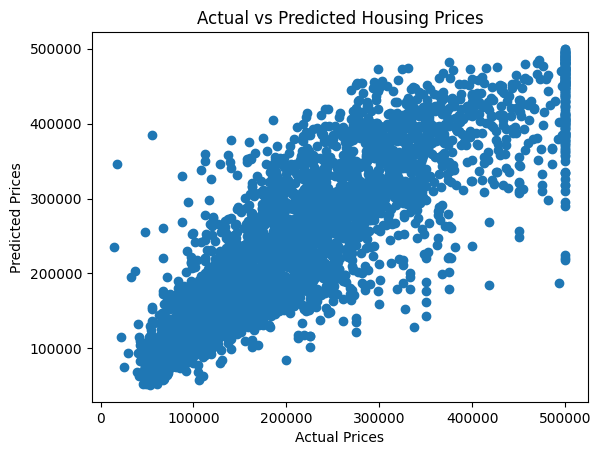

In [86]:
predictions = grid_search.best_estimator_.predict(test_data)
plt.scatter(test_labels, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()